# Avaliação de previsões (rolling forecast)

Este notebook avalia os arquivos `janela_*.csv` da pasta `previsoes/` usando três paradigmas:

1. **first**: primeira previsão feita para cada `step`;
2. **median**: mediana de todas as previsões para cada `step`;
3. **last**: última previsão feita para cada `step`.

Saídas principais:

- Tabelas de **MAE** e **MSE** por série/canal e por janela de previsão;
- Gráficos de linha dessas métricas ao longo das janelas + agregado (média entre séries);
- Box-plots de MAE/MSE por série e agregado, para `first`, `median` e `last`;
- Gráficos de linha de série observada (preto) vs predição (vermelho).



=== Paradigma: first ===
Tabela MAE/MSE por janela e série (amostra):


,window_id,series,MAE,MSE
0,0,B3SA3,1.566321,2.627610
1,0,BBAS3,1.856245,3.588665
2,0,BBDC3,1.782342,3.218872
3,0,BBDC4,8.470193,71.854581
4,0,BBSE3,4.205309,18.213758


Tabela agregada MAE/MSE por janela (amostra):


,window_id,series,MAE,MSE
0,0,AGREGADO,3.191528,16.784081
1,1,AGREGADO,2.900096,15.271510
2,2,AGREGADO,2.982471,15.779534
3,3,AGREGADO,3.188265,17.379612
4,4,AGREGADO,3.115442,17.000320


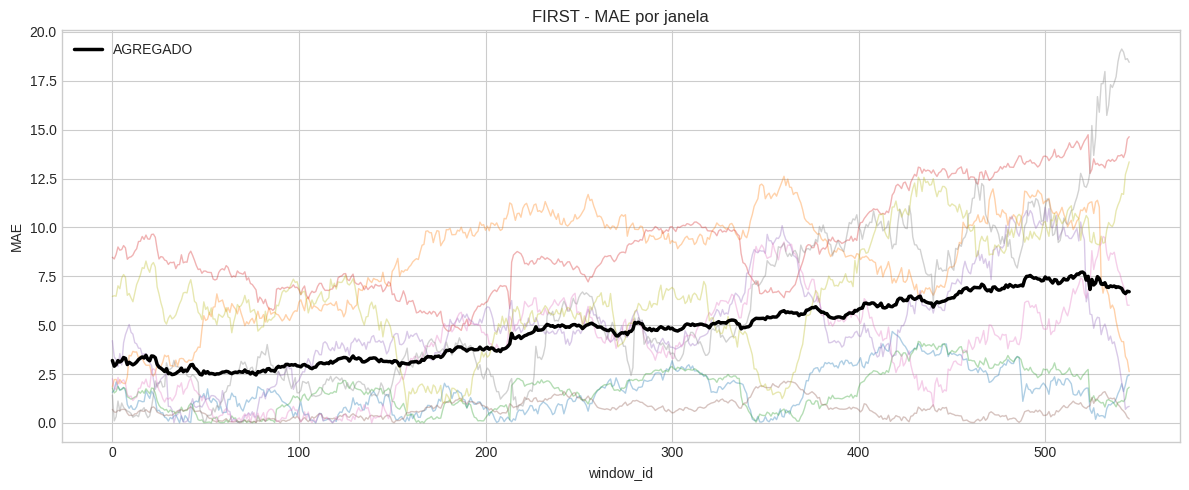

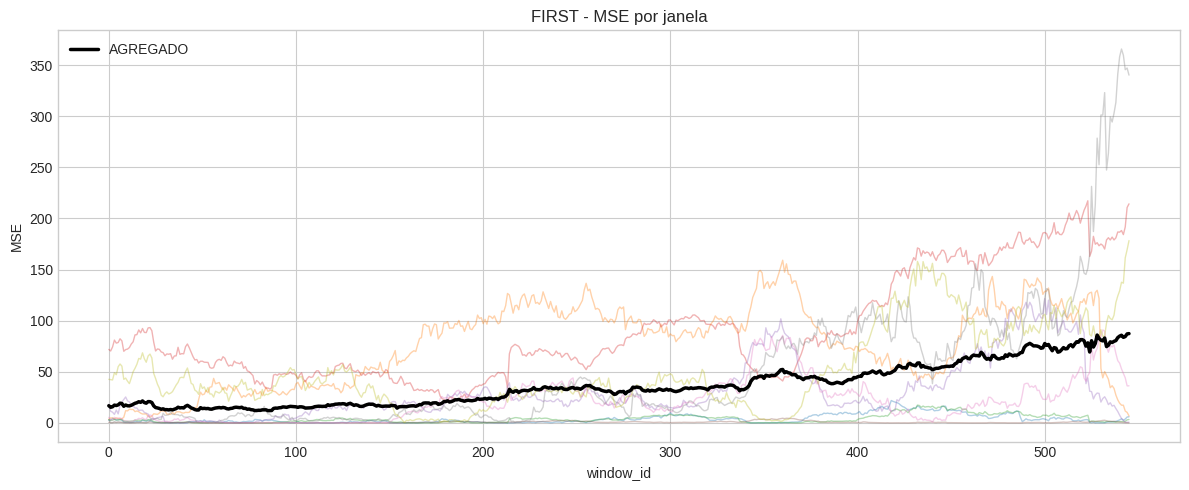

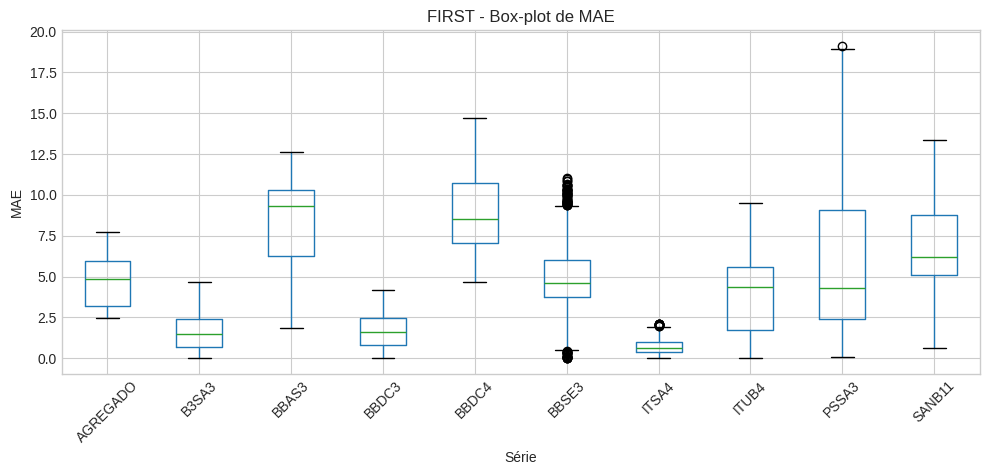

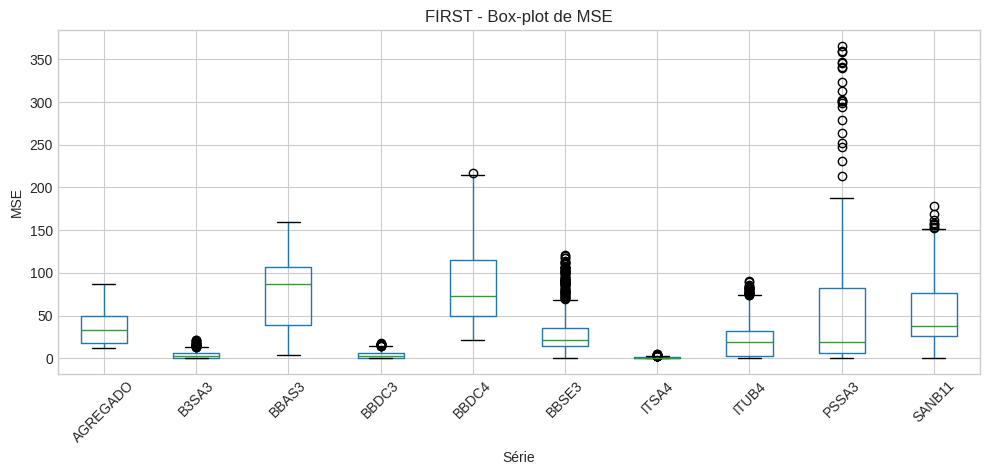

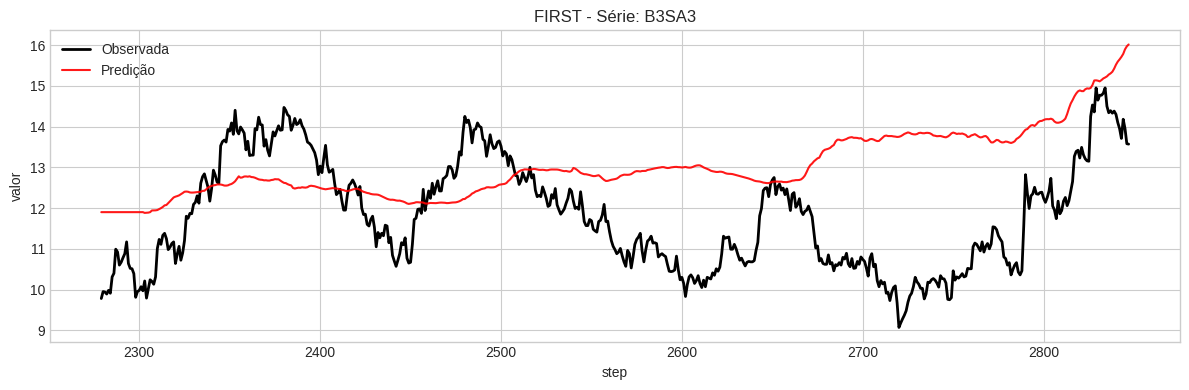

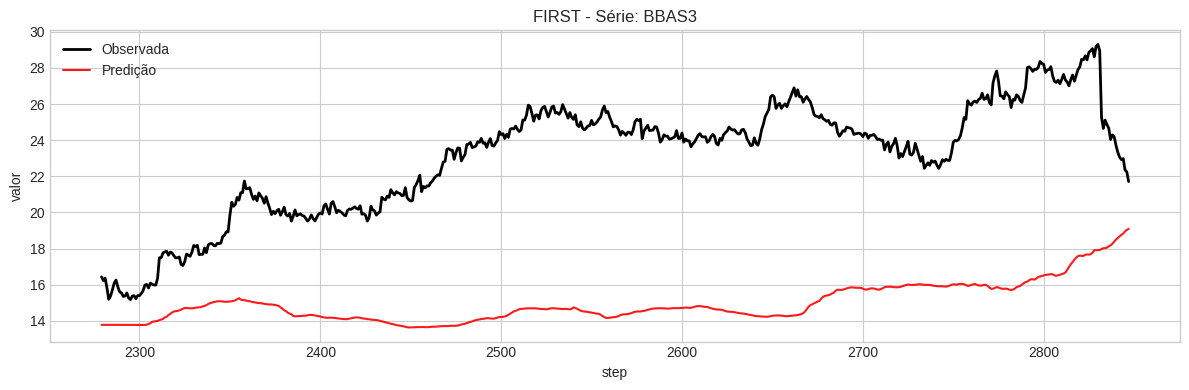

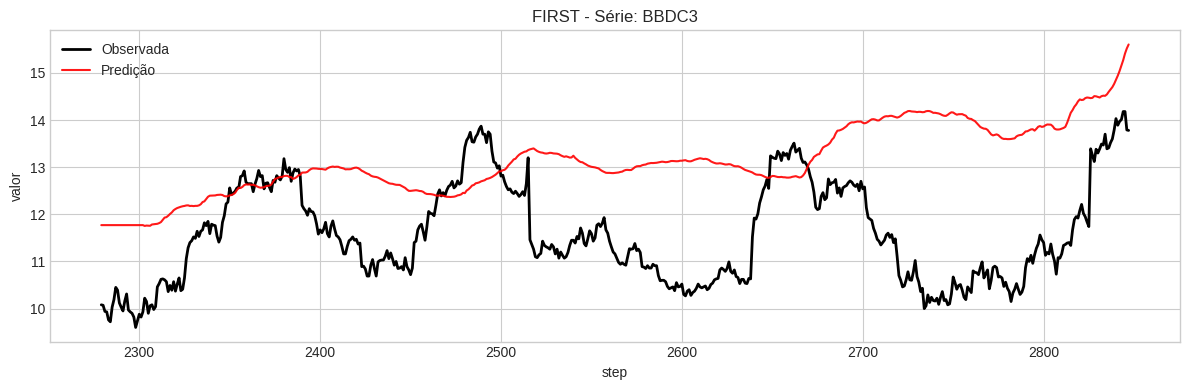

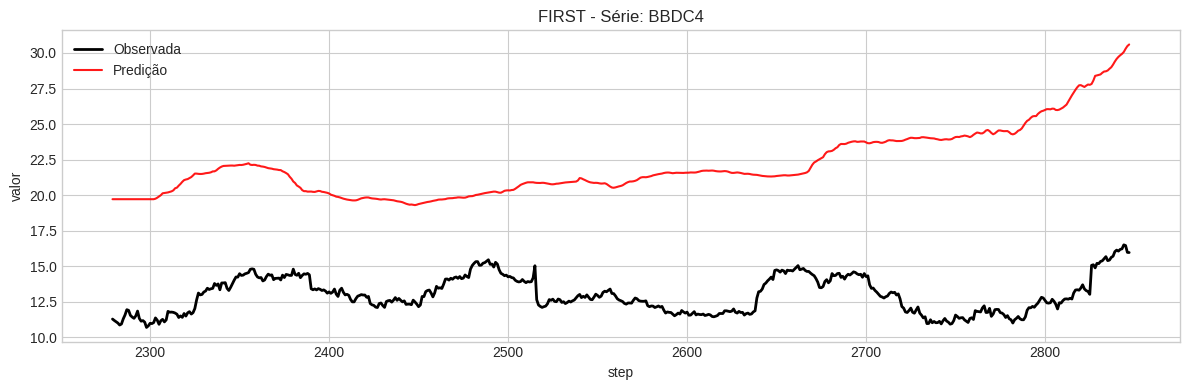

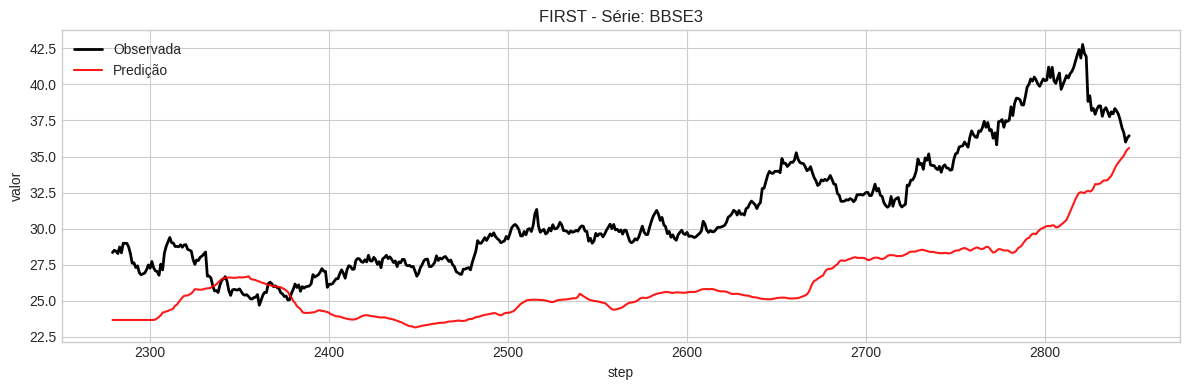

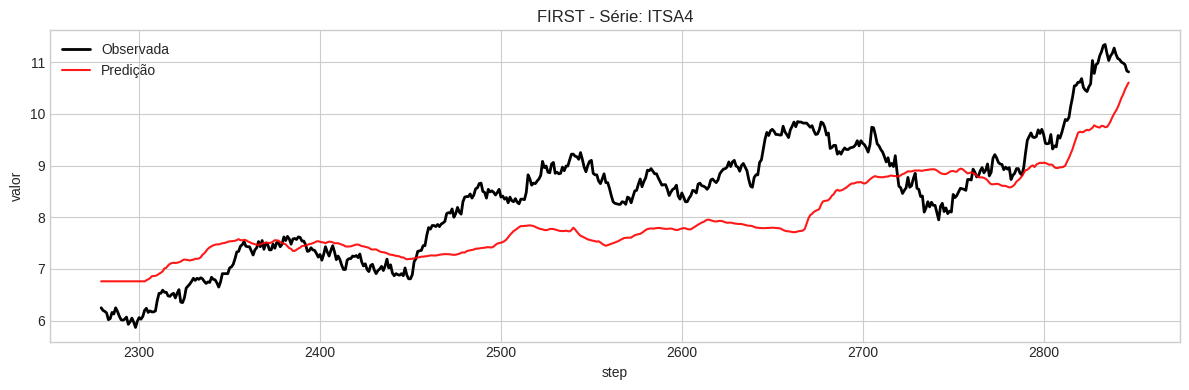

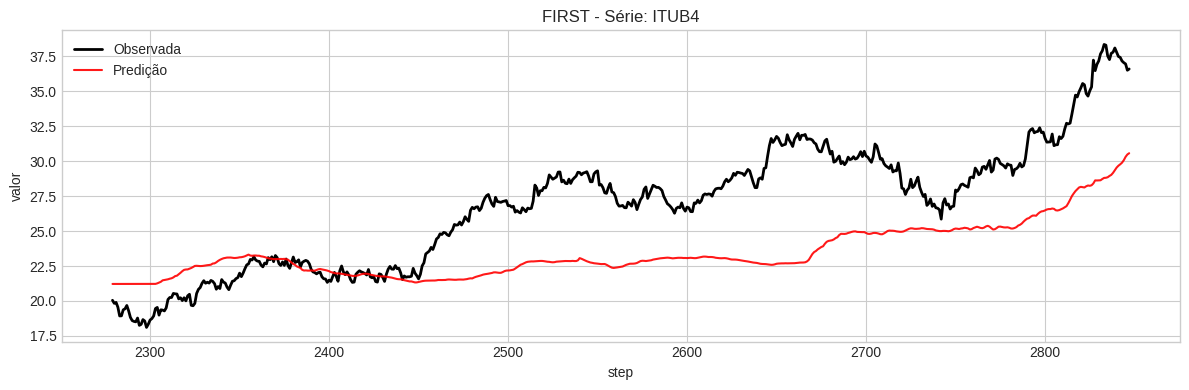

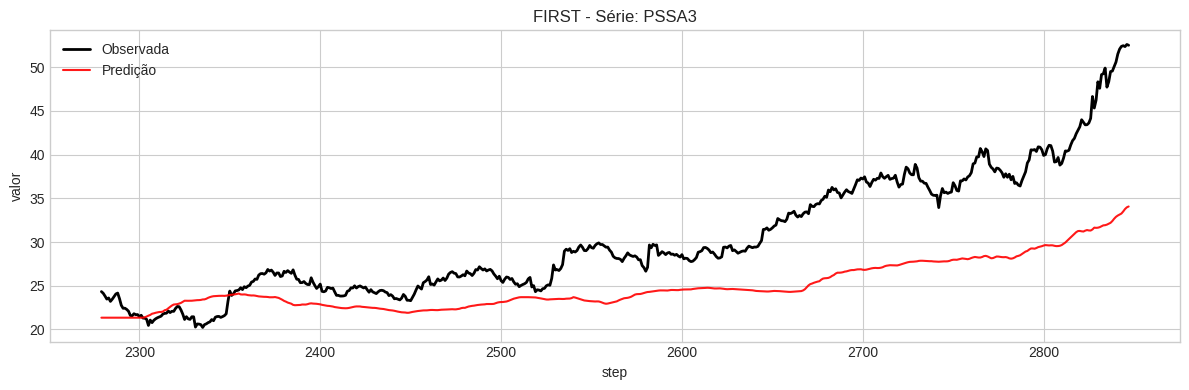

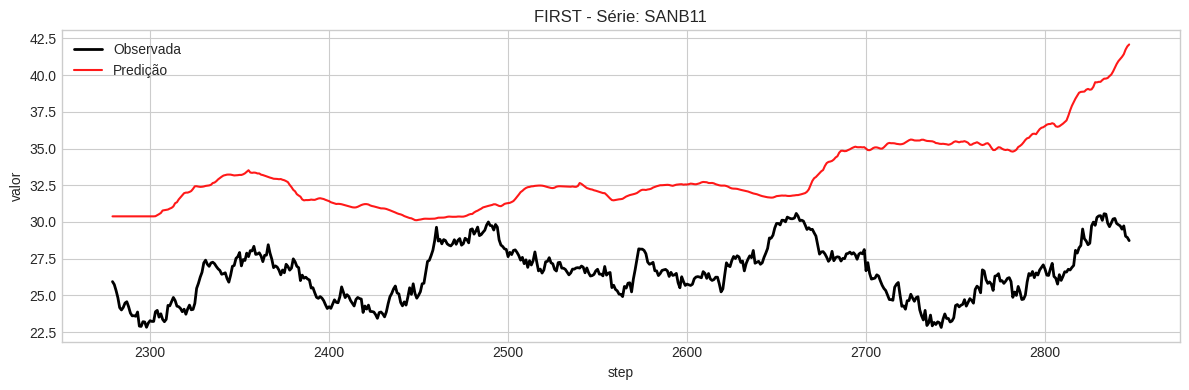


=== Paradigma: median ===
Tabela MAE/MSE por janela e série (amostra):


,window_id,series,MAE,MSE
0,0.0,B3SA3,2.120071,4.494701
1,0.0,BBAS3,2.657495,7.062280
2,0.0,BBDC3,1.690675,2.858382
3,0.0,BBDC4,8.431860,71.096263
4,0.0,BBSE3,4.674892,21.854615


Tabela agregada MAE/MSE por janela (amostra):


,window_id,series,MAE,MSE
0,0.0,AGREGADO,3.186708,15.292026
1,0.5,AGREGADO,3.203133,15.610723
2,1.0,AGREGADO,3.236973,16.077888
3,1.5,AGREGADO,3.232479,16.397967
4,2.0,AGREGADO,3.413540,18.267757


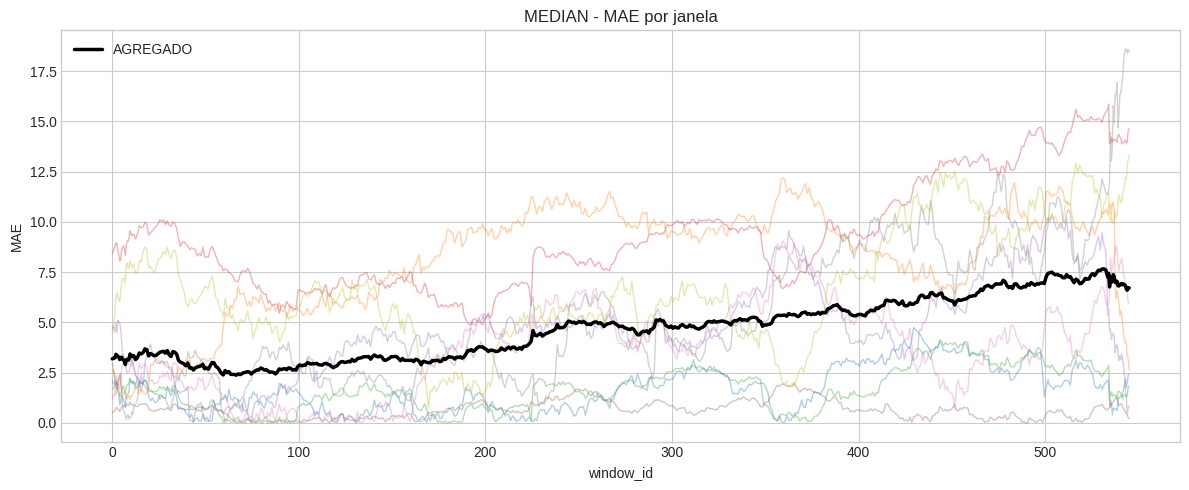

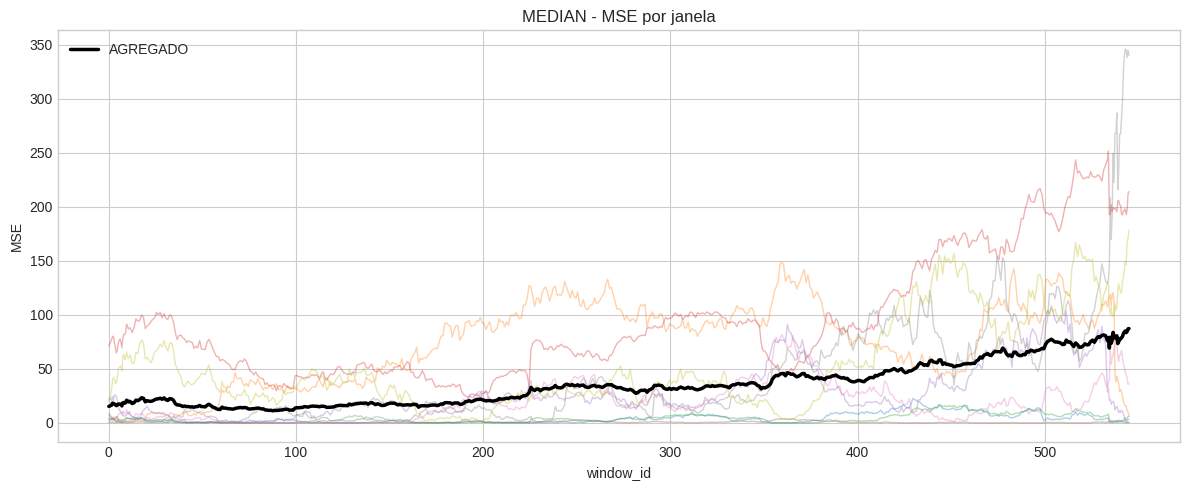

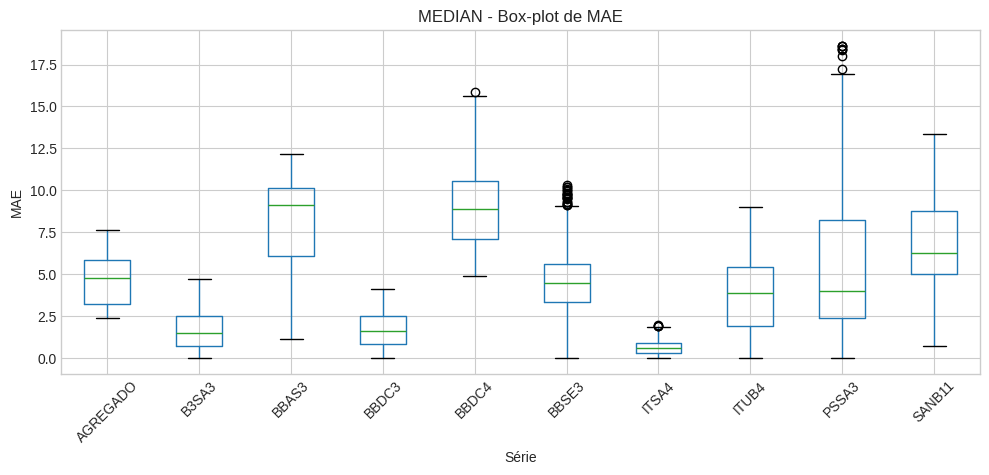

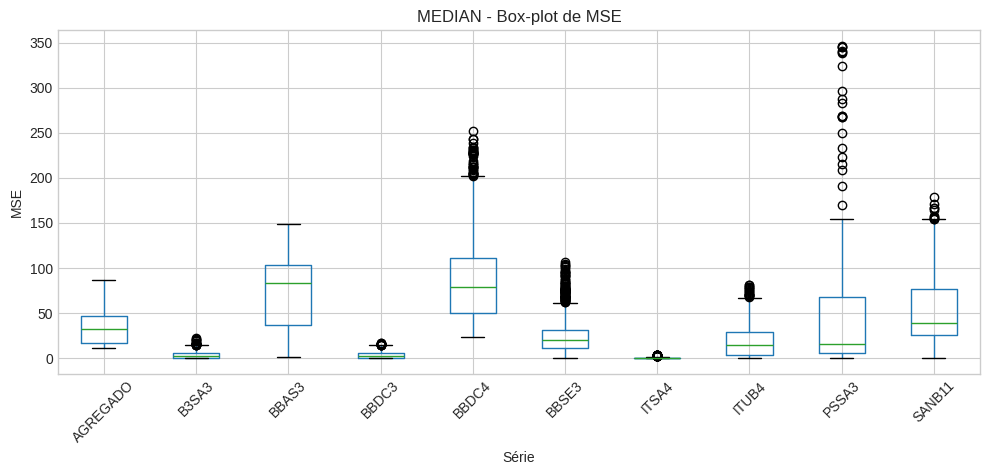

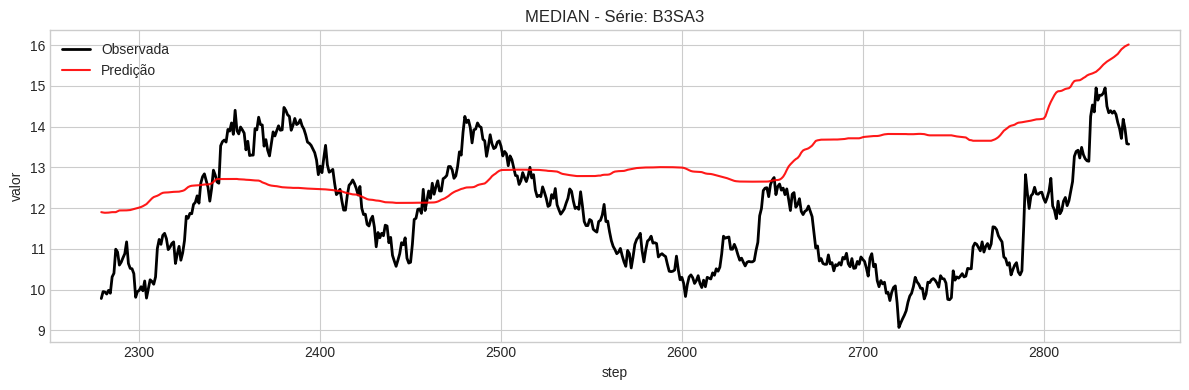

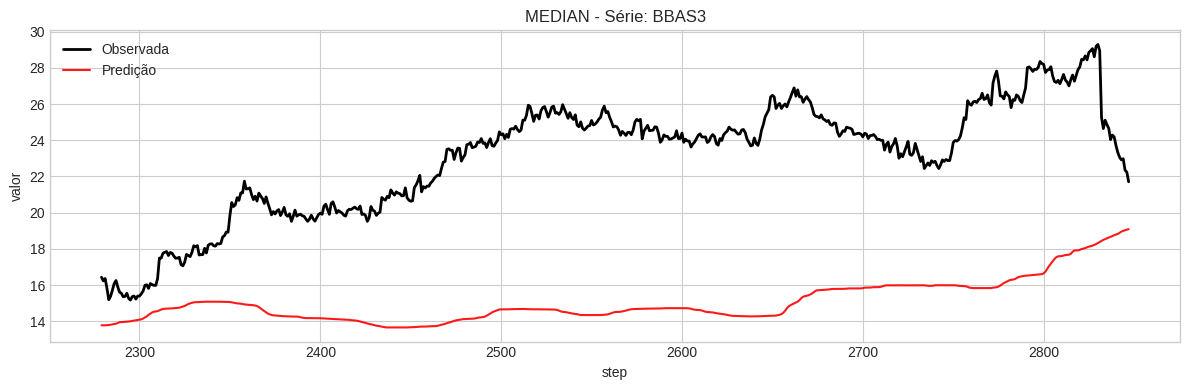

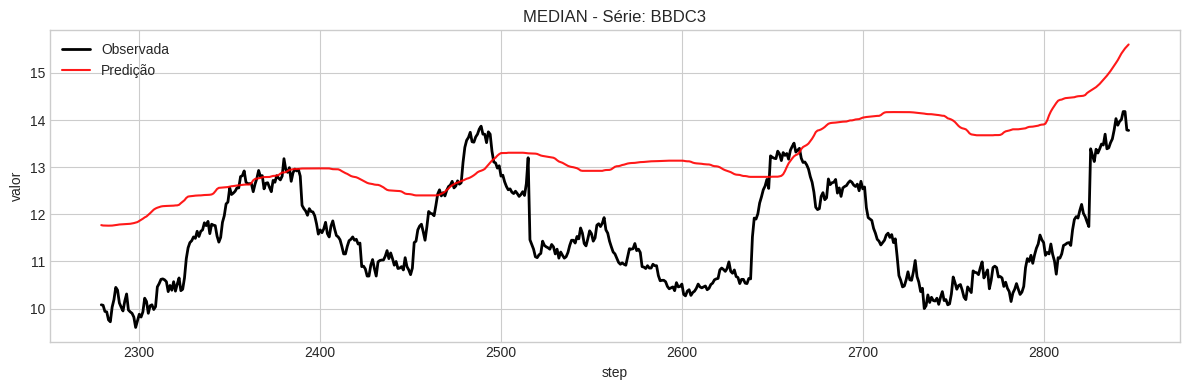

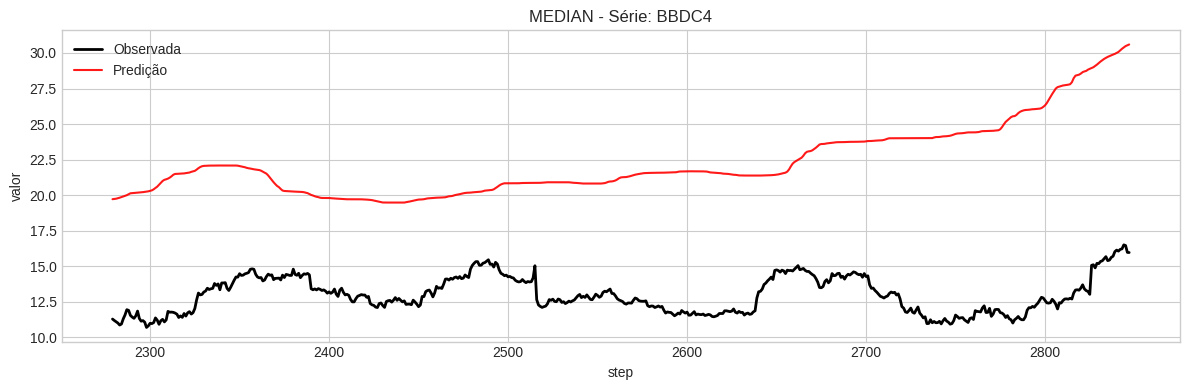

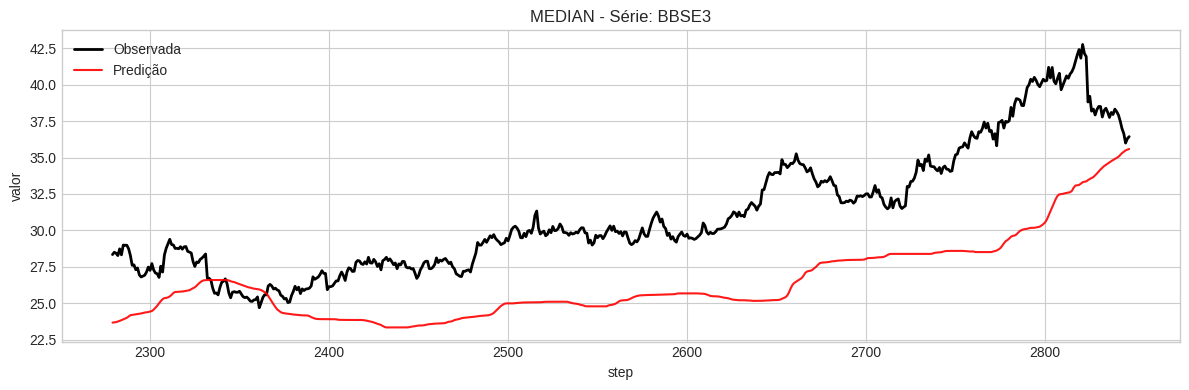

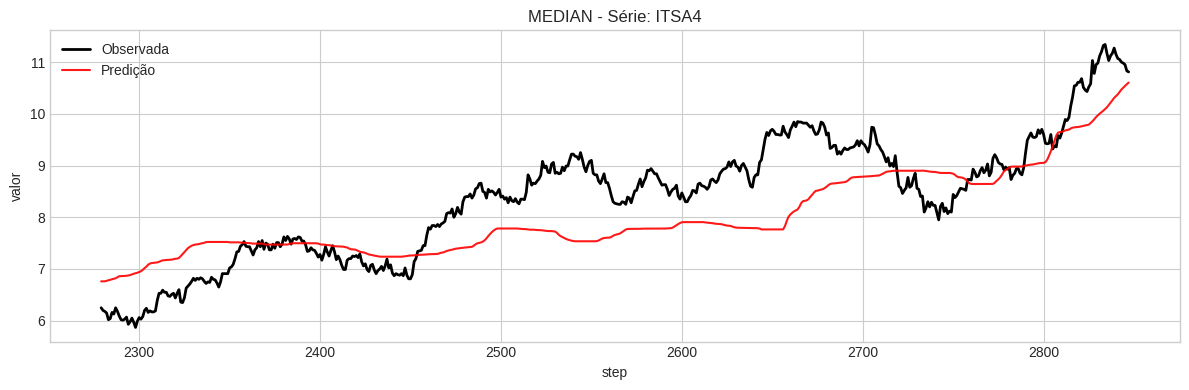

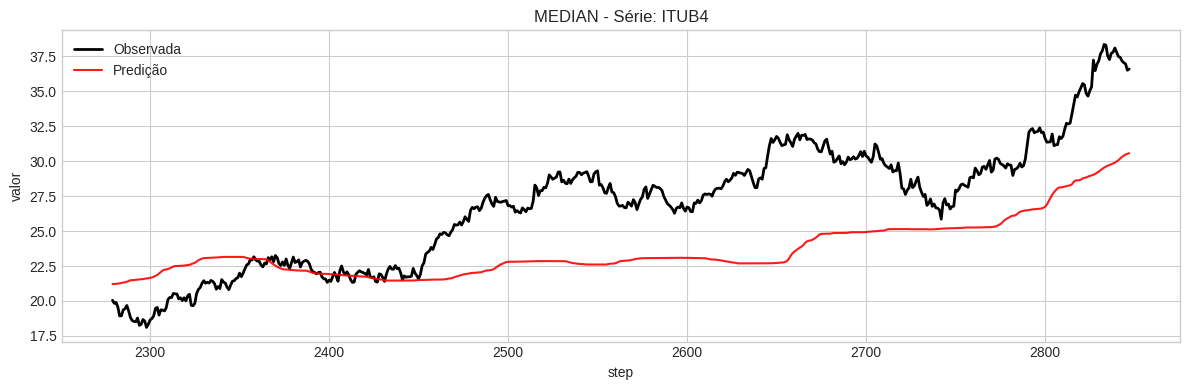

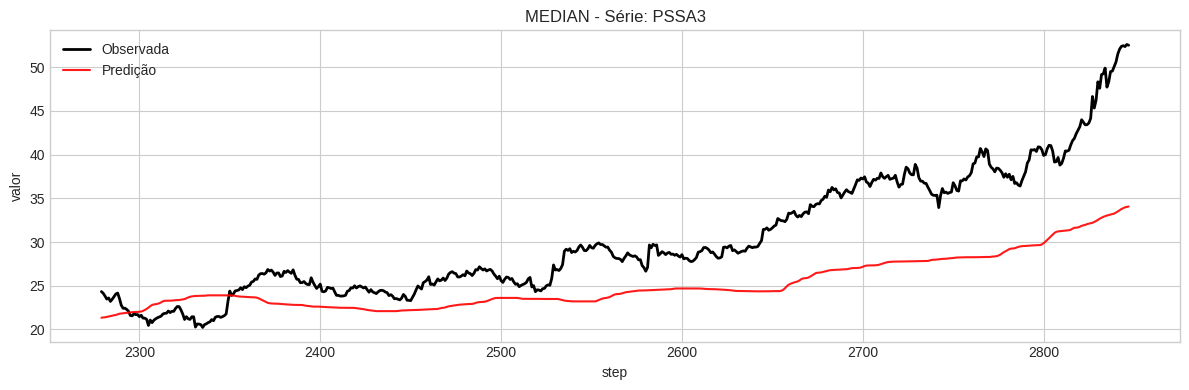

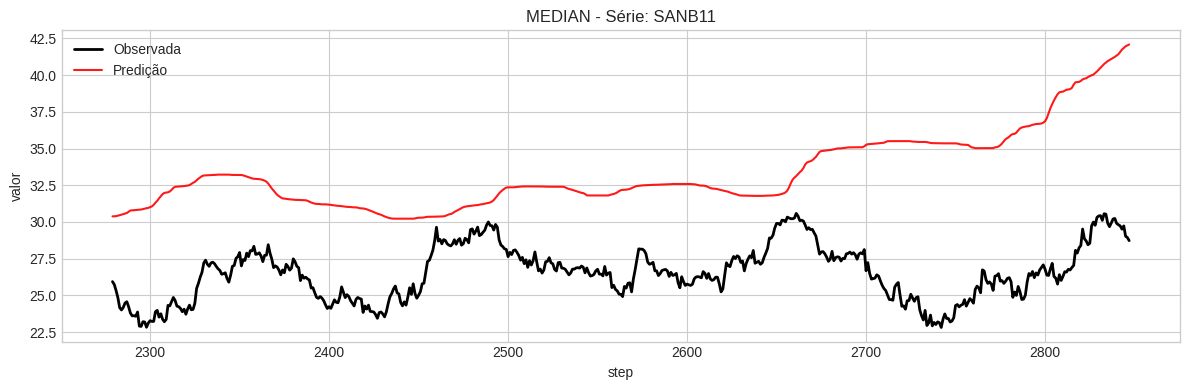


=== Paradigma: last ===
Tabela MAE/MSE por janela e série (amostra):


,window_id,series,MAE,MSE
0,0,B3SA3,2.120071,4.494701
1,0,BBAS3,2.657495,7.062280
2,0,BBDC3,1.690675,2.858382
3,0,BBDC4,8.431860,71.096263
4,0,BBSE3,4.674892,21.854615


Tabela agregada MAE/MSE por janela (amostra):


,window_id,series,MAE,MSE
0,0,AGREGADO,3.186708,15.292026
1,1,AGREGADO,3.199557,15.610680
2,2,AGREGADO,3.238879,16.168473
3,3,AGREGADO,3.233454,16.586493
4,4,AGREGADO,3.415250,18.572199


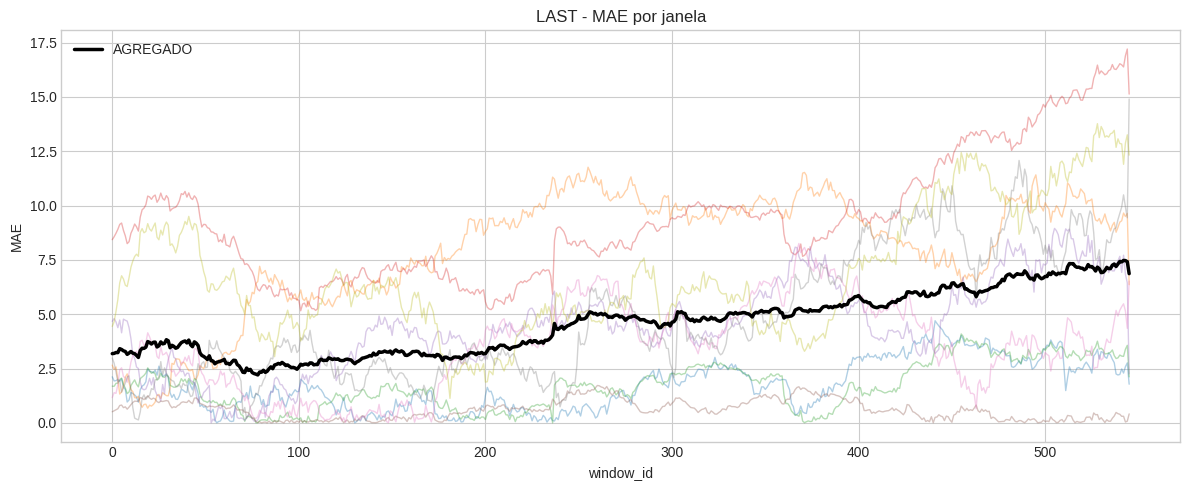

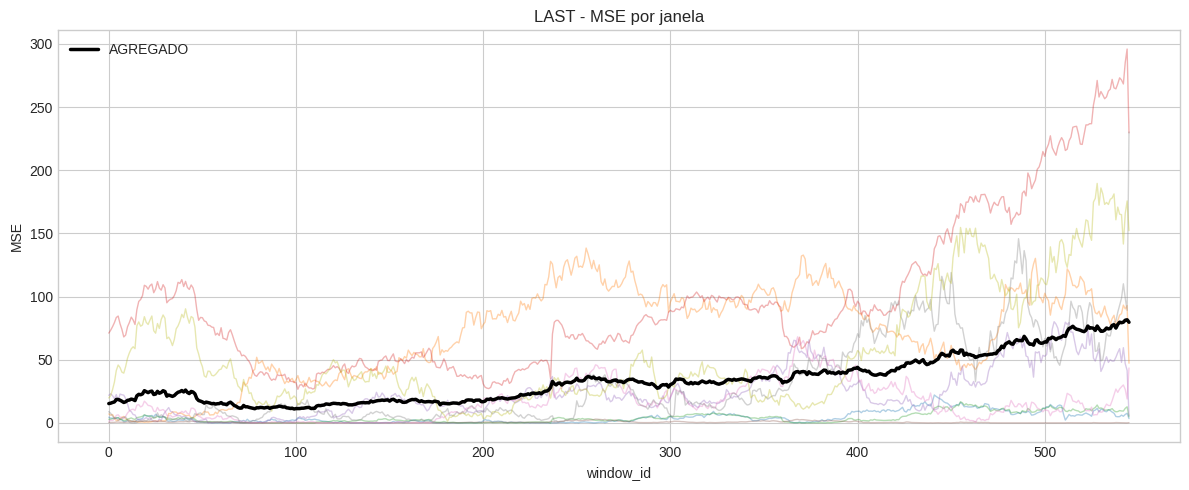

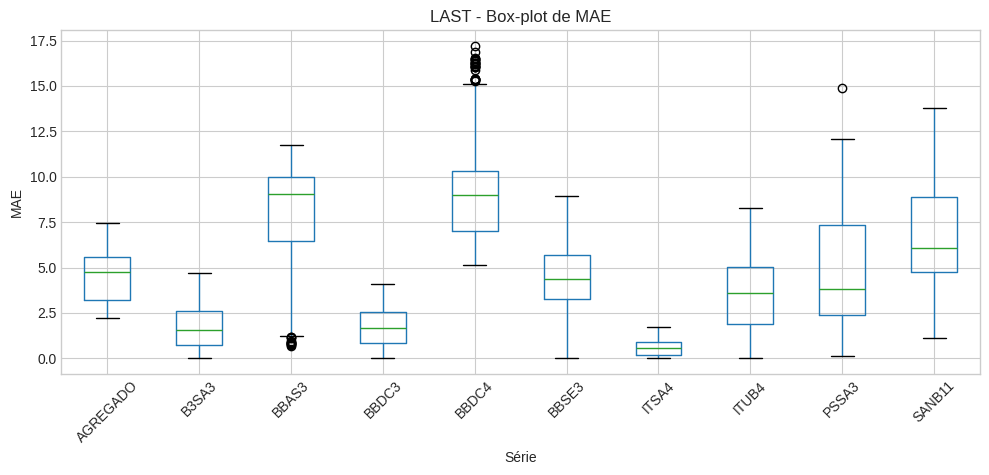

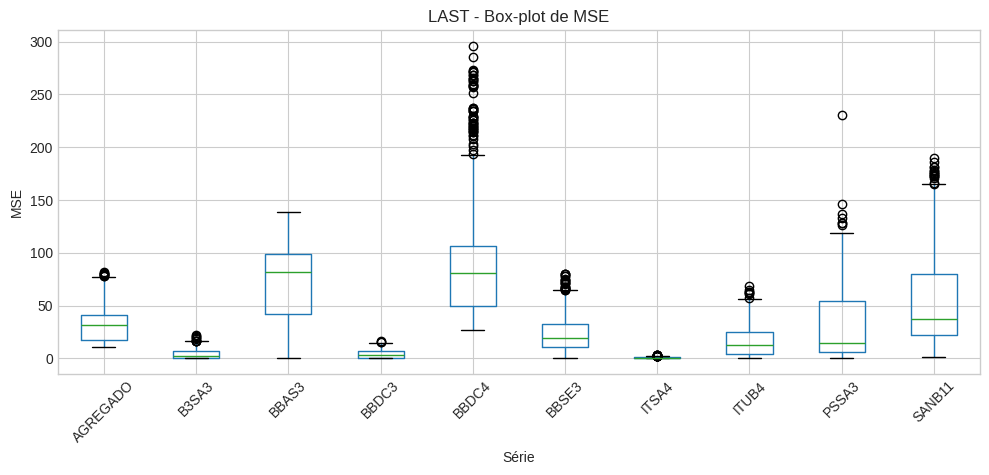

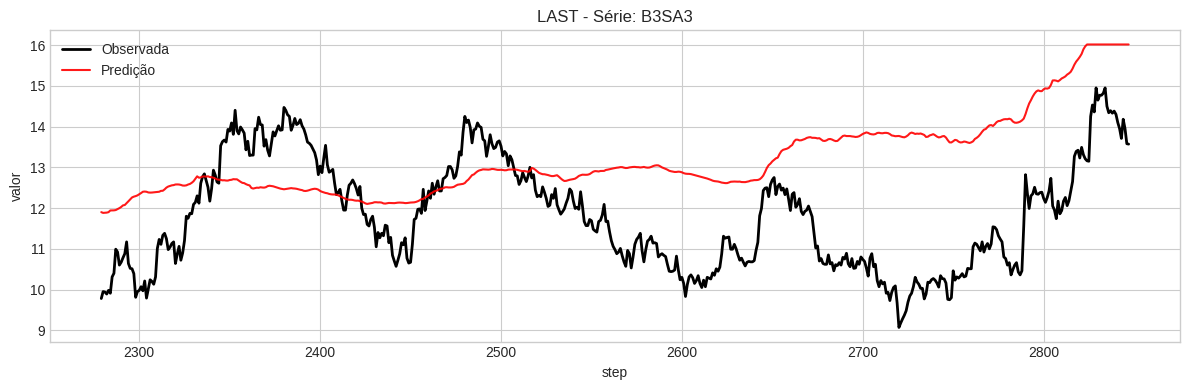

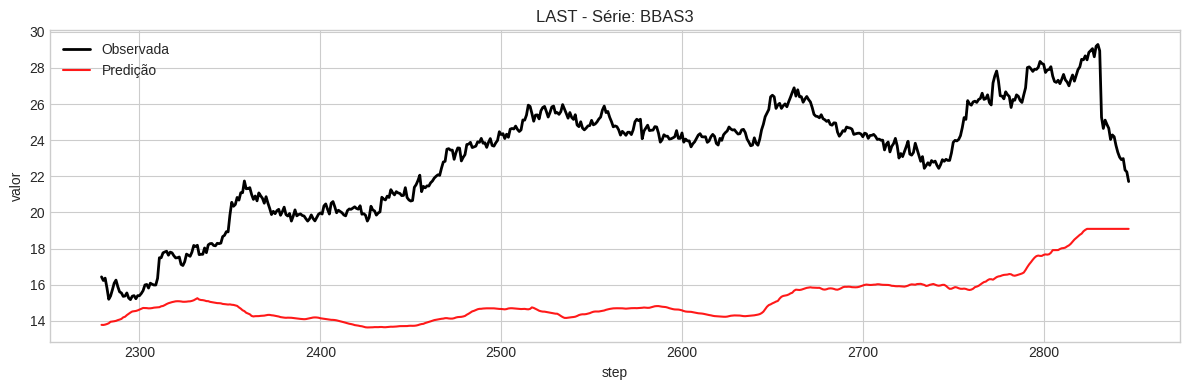

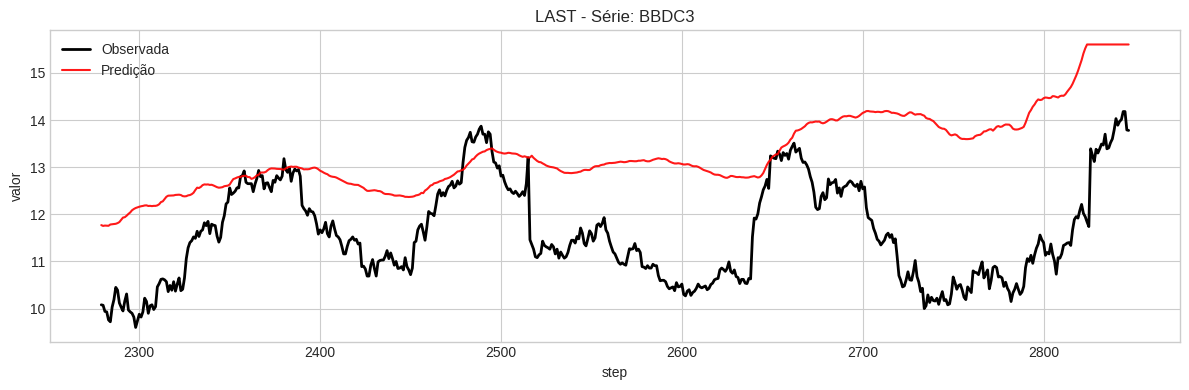

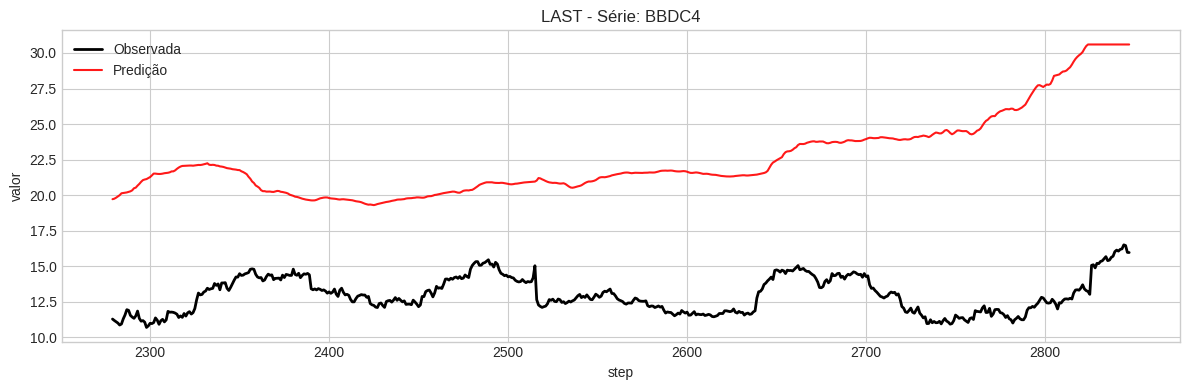

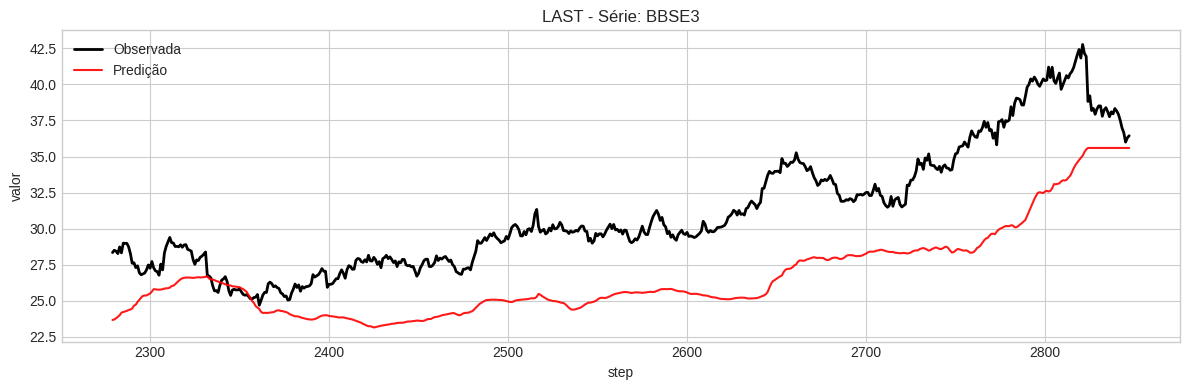

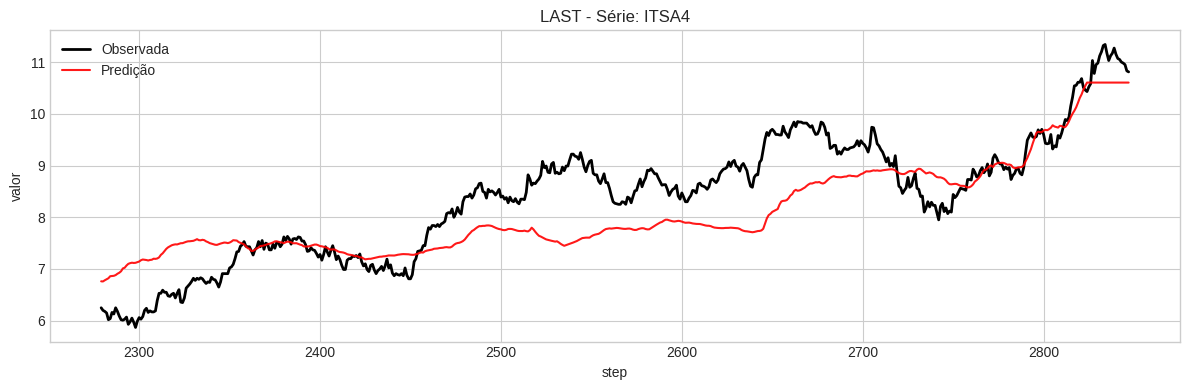

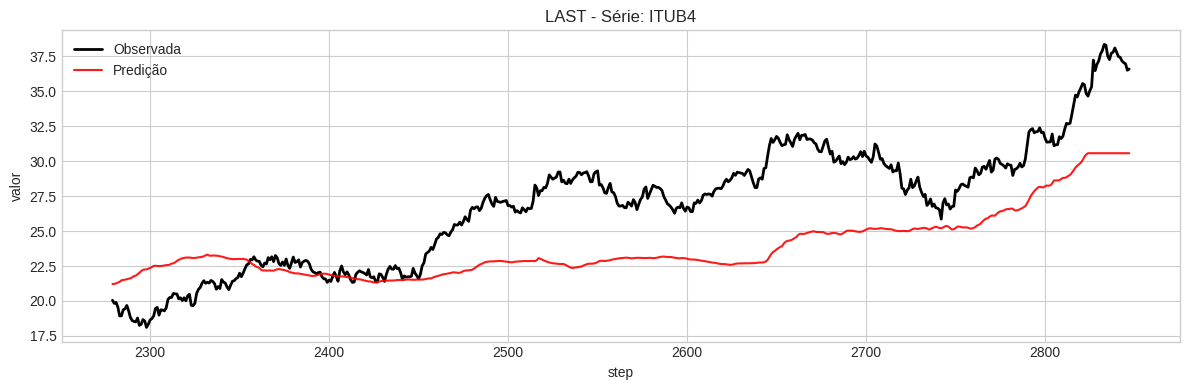

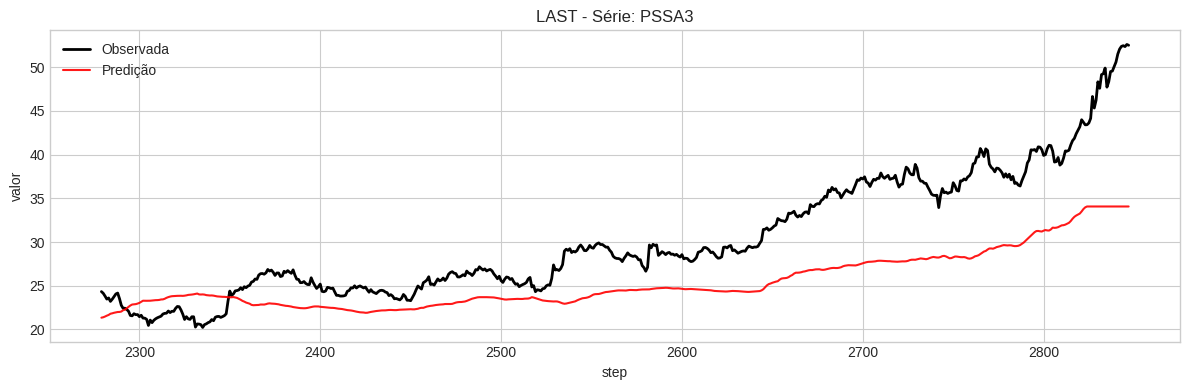

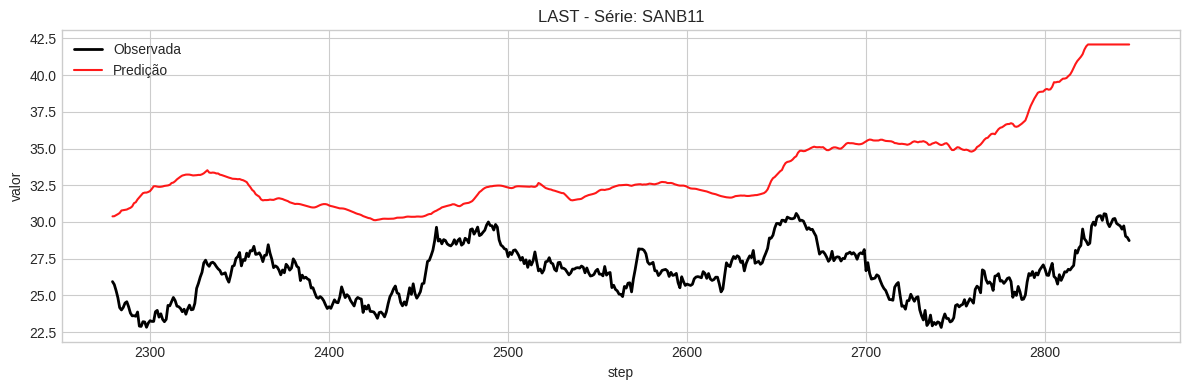


Notebook de avaliação pronto. Resultados disponíveis no dicionário `results`.


In [7]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


# =========================
# Configuração
# =========================
DATA_PATH = Path("../data/b3_daily_financeiro.csv")
PREDICTIONS_DIR = Path("../previsoes")

# Opcional: limitar quantidade de janelas para exploração rápida
MAX_WINDOWS = None  # ex.: 200


# =========================
# Utilidades de carregamento
# =========================
def load_real_series(data_path: Path) -> pd.DataFrame:
    """
    Espera um CSV longo no formato do loader:
      - date
      - cols (nome da série/canal)
      - data (valor observado)

    Retorna DataFrame wide indexado por step inteiro e colunas por série.
    """
    df = pd.read_csv(data_path)
    expected = {"date", "cols", "data"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"CSV real inválido. Colunas ausentes: {missing}")

    pivot = df.pivot(index="date", columns="cols", values="data")
    pivot = pivot.ffill().bfill()
    pivot = pivot.reset_index(drop=True)
    pivot.index.name = "step"
    return pivot


def load_prediction_windows(predictions_dir: Path, max_windows=None) -> pd.DataFrame:
    """
    Lê arquivos janela_*.csv e devolve DataFrame longo com colunas:
      - window_id
      - step
      - series
      - pred
    """
    files = sorted(predictions_dir.glob("janela_*.csv"))
    if max_windows is not None:
        files = files[:max_windows]

    if not files:
        raise FileNotFoundError(
            f"Nenhum arquivo janela_*.csv encontrado em {predictions_dir.resolve()}"
        )

    rows = []
    for w_id, fp in enumerate(files):
        df_pred = pd.read_csv(fp)
        if "step" not in df_pred.columns:
            raise ValueError(f"Arquivo {fp.name} não possui coluna 'step'.")

        series_cols = [c for c in df_pred.columns if c != "step"]
        long_df = df_pred.melt(id_vars="step", value_vars=series_cols,
                               var_name="series", value_name="pred")
        long_df["window_id"] = w_id
        rows.append(long_df[["window_id", "step", "series", "pred"]])

    return pd.concat(rows, ignore_index=True)


# =========================
# Consolidação por paradigma
# =========================
def build_actual_long(real_wide: pd.DataFrame) -> pd.DataFrame:
    df = real_wide.reset_index().melt(
        id_vars="step", var_name="series", value_name="actual"
    )
    return df


def aggregate_predictions(pred_long: pd.DataFrame, method: str) -> pd.DataFrame:
    """method in {'first', 'median', 'last'}"""
    if method not in {"first", "median", "last"}:
        raise ValueError("method deve ser 'first', 'median' ou 'last'.")

    g = pred_long.sort_values(["step", "series", "window_id"]).groupby(
        ["step", "series"], as_index=False
    )

    if method == "first":
        agg = g.first()
    elif method == "last":
        agg = g.last()
    else:
        agg = g["pred"].median()

    if "window_id" not in agg.columns:
        # no caso da mediana, mantemos uma referência temporal da janela mediana
        ref = g["window_id"].median().rename(columns={"window_id": "window_id_ref"})
        agg = agg.merge(ref, on=["step", "series"], how="left")
        agg = agg.rename(columns={"window_id_ref": "window_id"})

    return agg[["window_id", "step", "series", "pred"]]


def attach_actuals(agg_pred: pd.DataFrame, actual_long: pd.DataFrame) -> pd.DataFrame:
    df = agg_pred.merge(actual_long, on=["step", "series"], how="inner")
    df["residual"] = df["actual"] - df["pred"]
    df["abs_error"] = np.abs(df["residual"])
    df["sq_error"] = df["residual"] ** 2
    return df


# =========================
# Métricas por janela/série e agregado
# =========================
def metrics_by_window_series(eval_df: pd.DataFrame) -> pd.DataFrame:
    out = (
        eval_df.groupby(["window_id", "series"], as_index=False)
        .agg(MAE=("abs_error", "mean"), MSE=("sq_error", "mean"))
        .sort_values(["window_id", "series"])
    )
    return out


def metrics_aggregate(metrics_ws: pd.DataFrame) -> pd.DataFrame:
    """Agregado global = média simples entre séries em cada window_id."""
    agg = (
        metrics_ws.groupby("window_id", as_index=False)
        .agg(MAE=("MAE", "mean"), MSE=("MSE", "mean"))
        .sort_values("window_id")
    )
    agg["series"] = "AGREGADO"
    return agg[["window_id", "series", "MAE", "MSE"]]


# =========================
# Visualizações
# =========================
def plot_metric_lines(metrics_ws: pd.DataFrame, metric: str, title_prefix: str):
    series_list = sorted(metrics_ws["series"].unique())

    plt.figure(figsize=(12, 5))
    for s in series_list:
        sdf = metrics_ws[metrics_ws["series"] == s]
        plt.plot(sdf["window_id"], sdf[metric], alpha=0.35, linewidth=1)

    agg = metrics_aggregate(metrics_ws)
    plt.plot(agg["window_id"], agg[metric], color="black", linewidth=2.5, label="AGREGADO")
    plt.title(f"{title_prefix} - {metric} por janela")
    plt.xlabel("window_id")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_metric_boxplots(metrics_ws: pd.DataFrame, metric: str, title_prefix: str):
    base = metrics_ws[["series", metric]].copy()
    agg_rows = pd.DataFrame(
        {"series": ["AGREGADO"] * len(metrics_ws.groupby("window_id")),
         metric: metrics_ws.groupby("window_id")[metric].mean().values}
    )
    box_df = pd.concat([base, agg_rows], ignore_index=True)

    order = sorted([s for s in box_df["series"].unique() if s != "AGREGADO"]) + ["AGREGADO"]
    plt.figure(figsize=(max(10, len(order) * 0.8), 5))
    ax = plt.gca()
    box_df.boxplot(column=metric, by="series", rot=45, ax=ax)
    plt.suptitle("")
    plt.title(f"{title_prefix} - Box-plot de {metric}")
    plt.xlabel("Série")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


def plot_series_observed_vs_pred(eval_df: pd.DataFrame, title_prefix: str, max_series: int = None):
    series_list = sorted(eval_df["series"].unique())
    if max_series is not None:
        series_list = series_list[:max_series]

    for s in series_list:
        sdf = eval_df[eval_df["series"] == s].sort_values("step")
        plt.figure(figsize=(12, 4))
        plt.plot(sdf["step"], sdf["actual"], color="black", linewidth=2, label="Observada")
        plt.plot(sdf["step"], sdf["pred"], color="red", linewidth=1.5, alpha=0.9, label="Predição")
        plt.title(f"{title_prefix} - Série: {s}")
        plt.xlabel("step")
        plt.ylabel("valor")
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================
# Execução principal
# =========================
real_wide = load_real_series(DATA_PATH)
pred_long = load_prediction_windows(PREDICTIONS_DIR, max_windows=MAX_WINDOWS)
actual_long = build_actual_long(real_wide)

paradigms = ["first", "median", "last"]
results: Dict[str, Dict[str, pd.DataFrame]] = {}

for p in paradigms:
    agg_pred = aggregate_predictions(pred_long, method=p)
    eval_df = attach_actuals(agg_pred, actual_long)
    metrics_ws = metrics_by_window_series(eval_df)
    metrics_ag = metrics_aggregate(metrics_ws)

    results[p] = {
        "eval": eval_df,
        "metrics_window_series": metrics_ws,
        "metrics_aggregate": metrics_ag,
    }

    print(f"\n=== Paradigma: {p} ===")
    print("Tabela MAE/MSE por janela e série (amostra):")
    display(metrics_ws.head())
    print("Tabela agregada MAE/MSE por janela (amostra):")
    display(metrics_ag.head())

    # Linhas de MAE/MSE no tempo
    plot_metric_lines(metrics_ws, metric="MAE", title_prefix=f"{p.upper()}")
    plot_metric_lines(metrics_ws, metric="MSE", title_prefix=f"{p.upper()}")

    # Box-plots MAE/MSE por série + agregado
    plot_metric_boxplots(metrics_ws, metric="MAE", title_prefix=f"{p.upper()}")
    plot_metric_boxplots(metrics_ws, metric="MSE", title_prefix=f"{p.upper()}")

    # Observada (preto) vs predita (vermelho)
    plot_series_observed_vs_pred(eval_df, title_prefix=f"{p.upper()}", max_series=None)

print("\nNotebook de avaliação pronto. Resultados disponíveis no dicionário `results`.")
